Running Iberia
done HG
42.35566406250001


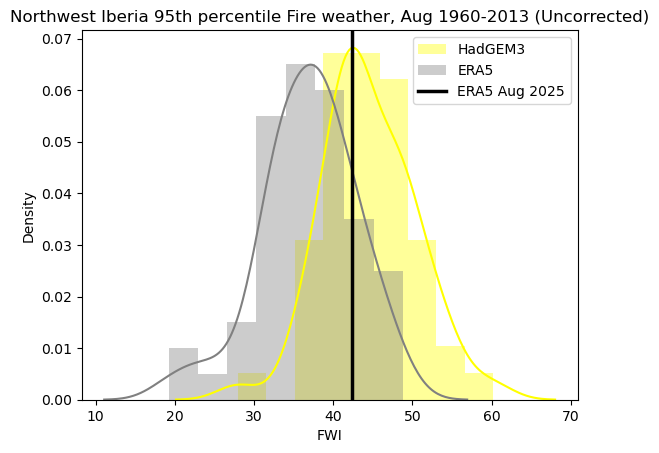

In [ ]:

import numpy as np
import iris
import time
#matplotlib.use('Agg')
import warnings
import os
import glob
import iris.coord_categorisation as icc
import re
import sys
import pandas as pd

from utils.constrain_cubes_standard import *
from utils.cubefuncs import *
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

############# User inputs here #############
Country = 'Iberia'

# Options: 'South Korea' (3), 'Iberia' (8), 'Scotland' (7)
############# User inputs end here #############


folder = '/data/scratch/chantelle.burton/SoW2526/'

#Set up the 2025 files and months automatically
if Country == 'South Korea':
    print('Running South Korea')
    Month = 3
    month = 'March'
    percentile = 95
    shape_name = 'Southeast South Korea'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-01-01-2025-05-31_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')
      
elif Country == 'Iberia':
    print('Running Iberia')
    Month = 8
    month = 'Aug'
    percentile = 95
    shape_name = 'Northwest Iberia'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')

elif Country == 'Scotland':
    print('Running Scotland')
    Month = 7
    month = 'July'
    percentile = 95
    shape_name = 'Scottish Highlands'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')


print('done HG')
ERA5_2025 = ERA5_2025.extract(daterange)
#Get the ERA5 2025 data for the threshold line
ERA5_2025 = contrain_to_sow_shapefile(ERA5_2025, '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp', 'Northwest Iberia')
ERA5_2025 = CountryPercentile(ERA5_2025, percentile)
ERA5_2025 = TimePercentile(ERA5_2025, percentile)
ERA5_2025 = np.array(ERA5_2025.data)
print(ERA5_2025)


##Make the plot
import seaborn as sns
HadGEM3_Arr = pd.read_csv('/data/scratch/bob.potts/sowf/test_output/HadGEM3_FWI_1960-2013_Iberia_10_95%.dat', header=None).values.flatten()
ERA5_ImpactsToolBox_Arr = pd.read_csv('/data/scratch/bob.potts/sowf/test_output/ERA5_FWI_1960-2013_Iberia_95%.dat', header=None).values.flatten()

##Make the plot
import seaborn as sns
sns.distplot(HadGEM3_Arr, hist=True, kde=True, 
             color = 'yellow', fit_kws={"linewidth":2.5,"color":"orange"}, label='HadGEM3')

sns.distplot(ERA5_ImpactsToolBox_Arr, hist=True, kde=True, 
             color = 'grey', fit_kws={"linewidth":2.5,"color":"black"}, label='ERA5')

plt.axvline(x=ERA5_2025, color='black', linewidth=2.5, label='ERA5 '+month+' 2025')


plt.xlabel('FWI')
plt.title('Northwest Iberia '+str(percentile)+'th percentile Fire weather, '+month+' 1960-2013 (Uncorrected)')
plt.legend(loc='best')
plt.show()





Running Iberia
done HG
42.35566406250001


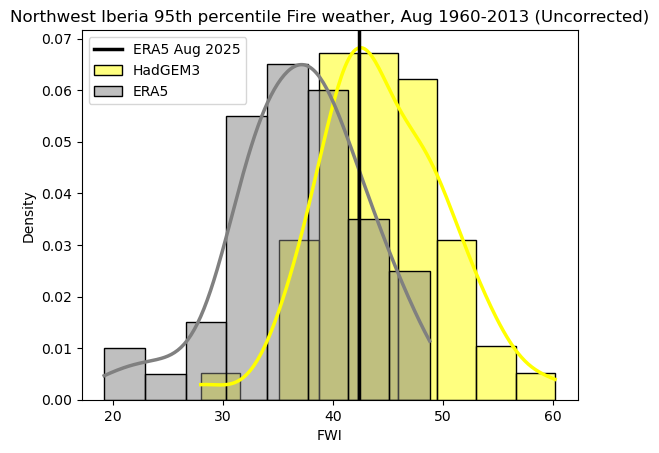

In [16]:
# ...existing code...
import numpy as np
import iris
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.constrain_cubes_standard import *
from utils.cubefuncs import *

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

############# User inputs here #############
Country = 'Iberia'

# Options: 'South Korea' (3), 'Iberia' (8), 'Scotland' (7)
############# User inputs end here #############

folder = '/data/scratch/chantelle.burton/SoW2526/'

# Set up the 2025 files and months automatically
percentile = 95

if Country == 'South Korea':
    print('Running South Korea')
    Month = 3
    month = 'March'
    shape_name = 'Southeast South Korea'
    era5_file = (
        "Y2526FWI/FWI_ERA5_std_reanalysis_2025-01-01-2025-05-31_global_day_"
        "initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-"
        "and-save-input-data=True.nc"
    )

elif Country == 'Iberia':
    print('Running Iberia')
    Month = 8
    month = 'Aug'
    shape_name = 'Northwest Iberia'
    era5_file = (
        "Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_"
        "initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-"
        "and-save-input-data=True.nc"
    )

elif Country == 'Scotland':
    print('Running Scotland')
    Month = 7
    month = 'July'
    shape_name = 'Scottish Highlands'
    era5_file = (
        "Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_"
        "initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-"
        "and-save-input-data=True.nc"
    )

else:
    raise ValueError(f"Unsupported Country: {Country}")

daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
ERA5_2025 = iris.load_cube(folder + era5_file, 'canadian_fire_weather_index')

print('done HG')
ERA5_2025 = ERA5_2025.extract(daterange)

# Get the ERA5 2025 data for the threshold line
ERA5_2025 = contrain_to_sow_shapefile(
    ERA5_2025,
    '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp',
    shape_name
)
ERA5_2025 = CountryPercentile(ERA5_2025, percentile)
ERA5_2025 = TimePercentile(ERA5_2025, percentile)
ERA5_2025 = np.array(ERA5_2025.data)
print(ERA5_2025)

# Make the plot
HadGEM3_Arr = pd.read_csv(
    '/data/scratch/bob.potts/sowf/test_output/HadGEM3_FWI_1960-2013_Iberia_10_95%.dat',
    header=None
).values.flatten()

ERA5_ImpactsToolBox_Arr = pd.read_csv(
    '/data/scratch/bob.potts/sowf/test_output/ERA5_FWI_1960-2013_Iberia_95%.dat',
    header=None
).values.flatten()

sns.histplot(
    HadGEM3_Arr,
    kde=True,
    stat="density",
    color='yellow',
    line_kws={"linewidth": 2.5, "color": "orange"},
    label='HadGEM3'
)

sns.histplot(
    ERA5_ImpactsToolBox_Arr,
    kde=True,
    stat="density",
    color='grey',
    line_kws={"linewidth": 2.5, "color": "black"},
    label='ERA5'
)


plt.axvline(x=ERA5_2025, color='black', linewidth=2.5, label='ERA5 ' + month + ' 2025')

plt.xlabel('FWI')
plt.title('Northwest Iberia ' + str(percentile) + 'th percentile Fire weather, ' + month + ' 1960-2013 (Uncorrected)')
plt.legend(loc='best')
plt.show()
# ...existing code...

In [ ]:
#branding - check banding guidline for correct colour shcme